In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Check what sheets are available in the Excel file
xl_file = pd.ExcelFile("../data/SPFmicrodata.xlsx")
print("Available indicators:", xl_file.sheet_names)

# Load only the NGDP sheet
df = pd.read_excel("../data/SPFmicrodata.xlsx", sheet_name="NGDP")
print(f"\nLoaded NGDP sheet: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:", df.columns.tolist())

Available indicators: ['NGDP', 'PGDP', 'CPROF', 'UNEMP', 'EMP', 'INDPROD', 'HOUSING', 'TBILL', 'BOND', 'BAABOND', 'TBOND', 'RGDP', 'RCONSUM', 'RNRESIN', 'RRESINV', 'RFEDGOV', 'RSLGOV', 'RCBI', 'REXPORT', 'CPI5YR', 'PCE5YR', 'CPI10', 'PCE10', 'RGDP10', 'PROD10', 'STOCK10', 'BOND10', 'BILL10', 'PRGDP', 'PRPGDP', 'PRUNEMP', 'PRCCPI', 'PRCPCE', 'RECESS', 'CPI', 'CORECPI', 'PCE', 'COREPCE', 'UBAR', 'SPR_TBOND_TBILL', 'SPR_BAA_AAA', 'SPR_BAA_TBOND', 'SPR_AAA_TBOND', 'CPIF5', 'PCEF5', 'RR1_TBILL_PGDP', 'RR2_TBILL_PGDP', 'RR3_TBILL_PGDP', 'RR1_TBILL_CPI', 'RR2_TBILL_CPI', 'RR3_TBILL_CPI', 'RR1_TBILL_CCPI', 'RR2_TBILL_CCPI', 'RR3_TBILL_CCPI', 'RR1_TBILL_PCE', 'RR2_TBILL_PCE', 'RR3_TBILL_PCE', 'RR1_TBILL_CPCE', 'RR2_TBILL_CPCE', 'RR3_TBILL_CPCE']

Loaded NGDP sheet: 9145 rows × 12 columns

Column names: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'NGDP1', 'NGDP2', 'NGDP3', 'NGDP4', 'NGDP5', 'NGDP6', 'NGDPA', 'NGDPB']


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [3]:
df.head()

,YEAR,QUARTER,ID,INDUSTRY,NGDP1,NGDP2,NGDP3,NGDP4,NGDP5,NGDP6,NGDPA,NGDPB
0,1968,4,1,NaN,871.0,884.0,895.0,907.0,920.0,938.0,NaN,NaN
1,1968,4,2,NaN,871.0,891.0,910.0,929.0,958.0,973.0,NaN,NaN
2,1968,4,3,NaN,871.0,883.0,894.0,906.0,924.0,944.0,NaN,NaN
3,1968,4,4,NaN,871.0,885.0,891.0,902.0,919.0,937.0,NaN,NaN
4,1968,4,5,NaN,871.0,895.0,913.0,935.0,940.0,970.0,NaN,NaN


In [4]:
print(" Number of unique IDs:", df['ID'].nunique())
print(" Number of unique years:", df['YEAR'].nunique())
print(" Number of na values in NGDP6:", df['NGDP6'].isna().sum())

 Number of unique IDs: 462
 Number of unique years: 58
 Number of na values in NGDP6: 974


Forecasts for the quarterly and annual level of nominal GDP. Seasonally
adjusted, annual rate, billions $. Prior to 1992, these are forecasts for
nominal GNP. Annual forecasts are for the annual average of the quarterly
levels.

First survey to include this variable: 1968:Q4


https://www.philadelphiafed.org/-/media/FRBP/Assets/Surveys-And-Data/survey-of-professional-forecasters/spf-documentation.pdf?sc_lang=en&hash=8408A4F1BF351A3C268B40F6BC7B95AA


Realized NGDP according to philadelphiafed website


https://www.philadelphiafed.org/surveys-and-data/real-time-data-research/noutput


Columns are the date of the vintage

For each target quarter t in your SPF panel, we want the first available vintage for that quarter — which is the advance estimate, published in the middle of the month immediately following the end of quarter t:

In [5]:
# ── 1. Load the NOUTPUT vintage matrix ────────────────────────────────────────
noutput = pd.read_excel("../data/NOUTPUTQvQd.xlsx")

# The DATE column looks like "1947:Q1" — parse into YEAR and QUARTER
noutput[["YEAR", "QUARTER"]] = (
    noutput["DATE"]
    .str.extract(r"(\d{4}):Q(\d)")
    .astype(int)
)
noutput = noutput.set_index(["YEAR", "QUARTER"])

# Drop the DATE column if still present
noutput = noutput.drop(columns=["DATE"], errors="ignore")

# ── 2. Build a helper: given a target (year, quarter), 
#       return the advance estimate vintage column name ─────────────────────────
def advance_vintage_col(target_year, target_quarter):
    """
    The advance estimate for a given quarter is published
    in the FOLLOWING quarter's vintage.
    e.g. target = 1995 Q2 → advance vintage = NOUTPUT95Q3
    """
    adv_quarter = target_quarter + 1
    adv_year    = target_year

    if adv_quarter > 4:
        adv_quarter = 1
        adv_year    = target_year + 1

    # Column name format: NOUTPUT95Q3 (2-digit year)
    col = f"NOUTPUT{str(adv_year)[2:]}Q{adv_quarter}"
    return col

# ── 3. Extract advance estimate for each target quarter ───────────────────────
def get_advance_estimate(target_year, target_quarter, noutput_df):
    """
    For a given target (year, quarter), return the advance estimate —
    i.e. the value in the FIRST vintage where that quarter was published.
    
    The advance estimate is published in the immediately following quarter:
        Q1 target → Q2 vintage of same year
        Q2 target → Q3 vintage of same year
        Q3 target → Q4 vintage of same year
        Q4 target → Q1 vintage of next year
    """
    col = advance_vintage_col(target_year, target_quarter)
    try:
        val = noutput_df.loc[(target_year, target_quarter), col]
        return val if not pd.isna(val) else np.nan
    except KeyError:
        return np.nan

# ── 4. Sanity check — a few known quarters ────────────────────────────────────
test_cases = [(1995, 2), (1999, 2), (2008, 4), (2020, 2)]
print("Sanity check — advance estimates:")
print(f"{'Target Quarter':<20} {'Vintage Col':<18} {'Value (bn $)'}")
print("-" * 55)
for y, q in test_cases:
    col = advance_vintage_col(y, q)
    val = get_advance_estimate(y, q, noutput)
    print(f"  {y}:Q{q:<16}  {col:<18}  {val:,.1f}")


Sanity check — advance estimates:
Target Quarter       Vintage Col        Value (bn $)
-------------------------------------------------------
  1995:Q2                 NOUTPUT95Q3         7,011.8
  1999:Q2                 NOUTPUT99Q3         8,893.3
  2008:Q4                 NOUTPUT09Q1         14,264.6
  2020:Q2                 NOUTPUT20Q3         19,408.8


Values should be in the thousands of billions and grow over time — that is the sanity check. If they look right, we move to merging with your individual SPF panel.

In [6]:
# ── NOUTPUT vintage matrix (already loaded and indexed) ───────────────────────
# Assumes noutput is indexed by (YEAR, QUARTER) with columns like 'NOUTPUT95Q3'
# ── Horizon offsets (unchanged) ───────────────────────────────────────────────
# NGDP1 = t-1 (previous quarter historical)
# NGDP2 = t+0 (nowcast, current quarter)
# NGDP3 = t+1, NGDP4 = t+2, NGDP5 = t+3, NGDP6 = t+4
horizon_offsets = {
    'NGDP1': -1,
    'NGDP2':  0,
    'NGDP3':  1,
    'NGDP4':  2,
    'NGDP5':  3,
    'NGDP6':  4,
}

# ── Build errors DataFrame ────────────────────────────────────────────────────
errors_df = df[['YEAR', 'QUARTER', 'ID', 'INDUSTRY'] + list(horizon_offsets.keys())].copy()

for col, offset in horizon_offsets.items():

    # Step 1: compute the target (year, quarter) for this horizon
    total   = (errors_df['YEAR'] - 1) * 4 + (errors_df['QUARTER'] - 1) + offset
    t_year  = ((total // 4) + 1).astype(int)
    t_qtr   = ((total  % 4) + 1).astype(int)

    # Step 2: look up the advance estimate from the correct vintage
    gdp_actual = np.array([
        get_advance_estimate(y, q, noutput)
        for y, q in zip(t_year, t_qtr)
    ])

    # Step 3: compute forecast error (forecast - actual)
    errors_df[f'error_{col}'] = errors_df[col].values - gdp_actual
    errors_df.drop(columns=[col], inplace=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
print("Shape:", errors_df.shape)
print("\nError summary (should be small relative to GDP levels ~thousands of bn$):")
for col in [f'error_NGDP{i}' for i in range(1, 7)]:
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.1f}, "
              f"std={errors_df[col].std():.1f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

# print the rows between 1998 Q4 and 2000 Q2 to check the dot-com bust period
mask = ((errors_df['YEAR'] == 1998) & (errors_df['QUARTER'] == 4)) | \
       ((errors_df['YEAR'] == 1999) & (errors_df['QUARTER'].isin([1, 2, 3, 4]))) | \
       ((errors_df['YEAR'] == 2000) & (errors_df['QUARTER'].isin([1, 2])))
print("\nErrors during dot-com bust period (1998 Q4 to 2000 Q2):")
print(errors_df[mask][['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'error_NGDP2', 'error_NGDP3']])


Shape: (9145, 10)

Error summary (should be small relative to GDP levels ~thousands of bn$):
  error_NGDP1: mean=+0.3, std=6.1, nan%=6.1%
  error_NGDP2: mean=-15.0, std=118.9, nan%=6.5%
  error_NGDP3: mean=-20.4, std=258.5, nan%=6.9%
  error_NGDP4: mean=-25.4, std=313.2, nan%=7.5%
  error_NGDP5: mean=-30.7, std=372.2, nan%=7.9%
  error_NGDP6: mean=-32.2, std=441.6, nan%=12.7%

Errors during dot-com bust period (1998 Q4 to 2000 Q2):
      YEAR  QUARTER   ID  INDUSTRY  error_NGDP2  error_NGDP3
4853  1998        4   20       2.0      -29.900      -78.400
4854  1998        4   40       2.0      -63.700     -103.000
4855  1998        4   65       2.0     -103.984     -181.821
4856  1998        4   84       1.0      -34.800      -79.900
4857  1998        4   99       1.0      -89.800     -104.900
...    ...      ...  ...       ...          ...          ...
5101  2000        2  507       3.0     -129.300      -83.300
5102  2000        2  508       2.0      -92.200     -111.000
5103  2000     

In [7]:
# let's only keep NGDP3 errors for now
errors_df = errors_df[['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'error_NGDP3']].copy()
errors_df['squared_error_NGDP3'] = errors_df['error_NGDP3']**2

errors_df.head()

,YEAR,QUARTER,ID,INDUSTRY,error_NGDP3,squared_error_NGDP3
0,1968,4,1,NaN,-8.4,70.56
1,1968,4,2,NaN,6.6,43.56
2,1968,4,3,NaN,-9.4,88.36
3,1968,4,4,NaN,-12.4,153.76
4,1968,4,5,NaN,9.6,92.16


In [8]:
# Count observations per forecaster alongside their MSE
forecaster_stats = (
    errors_df
    .groupby('ID')['squared_error_NGDP3']
    .agg(mean_mse='mean', n_obs='count')
    .sort_values('mean_mse')
)

print(forecaster_stats.head(20))
print(f"\nForecasters with < 5 observations: "
      f"{(forecaster_stats['n_obs'] < 5).sum()}")
print(f"Forecasters with >= 20 observations: "
      f"{(forecaster_stats['n_obs'] >= 20).sum()}")

       mean_mse  n_obs
ID                    
116    1.600000      2
163    3.240000      1
137   16.000000      1
489   20.250000      1
139   21.200000      2
160   23.040000      1
24    37.085000      2
141   46.300000      4
114   54.932500      4
165   67.240000      1
45    71.486667      3
113   77.440000      1
71    93.185000      2
29   106.065000      6
11   108.160000      1
52   114.826842     19
306  116.500000      2
6    125.486250      8
122  126.646000     10
83   139.385556      9

Forecasters with < 5 observations: 203
Forecasters with >= 20 observations: 148


The top-ranked forecasters all have 1–2 observations — their low MSE is pure luck, not genuine skill. Forecaster 163 with MSE=3.24 made exactly one forecast. That tells you nothing about forecasting ability.

In [9]:
# ── Step 1: Apply minimum observation filter ──────────────────────────────────
min_obs = 20
sq_error_col = 'squared_error_NGDP3'

# Keep only forecasters with enough observations
valid_ids = (
    errors_df
    .groupby('ID')[sq_error_col]
    .count()
    .loc[lambda x: x >= min_obs]
    .index
)

errors_filtered = errors_df[errors_df['ID'].isin(valid_ids)].copy()
print(f"Forecasters with >= {min_obs} obs: {len(valid_ids)}")

# ── Step 2: Pivot to wide format (rows=periods, cols=forecasters) ──────────────
errors_wide = errors_filtered.pivot_table(
    index=['YEAR', 'QUARTER'],
    columns='ID',
    values=sq_error_col
)

print(f"\nFull panel shape: {errors_wide.shape}")
print(f"(time periods × forecasters)")

# ── Step 3: Scan group sizes vs complete periods ───────────────────────────────
print("\nGroup size scan (top-N most frequent forecasters):")
print(f"{'N':>5} | {'Complete periods':>18} | {'Recommendation'}")
print("-" * 50)

for N in [5, 8, 10, 12, 15, 20, 25, 30]:
    top_ids  = errors_wide.notna().sum().nlargest(N).index
    complete = errors_wide[top_ids].dropna().shape[0]
    flag = " ← good" if complete >= 20 else (" ← marginal" if complete >= 10 else "")
    print(f"{N:>5} | {complete:>18} | {flag}")


Forecasters with >= 20 obs: 148

Full panel shape: (225, 148)
(time periods × forecasters)

Group size scan (top-N most frequent forecasters):
    N |   Complete periods | Recommendation
--------------------------------------------------
    5 |                 45 |  ← good
    8 |                 21 |  ← good
   10 |                  4 | 
   12 |                  3 | 
   15 |                  1 | 
   20 |                  0 | 
   25 |                  0 | 
   30 |                  0 | 


In [22]:
# ── Choose N and build the analysis panel ─────────────────────────────────────
N = 8
top_ids        = errors_wide.notna().sum().nlargest(N).index
X_wide         = errors_wide[top_ids]
X              = X_wide.values.astype(float)
population_ids = X_wide.columns.tolist()
n, p           = X.shape

print(f"Analysis panel: {n} time periods × {p} forecasters")
print(f"Forecaster IDs: {population_ids}")
print(f"\nMean squared errors (ranked):")
for i, fid in enumerate(population_ids):
    mse = np.nanmean(X[:, i]) 
    print(f"  ID {fid}: MSE = {mse:,.3f}  (RMSE ≈ {mse**0.5:,.2f} bn$)")

Analysis panel: 225 time periods × 8 forecasters
Forecaster IDs: [65, 426, 84, 433, 428, 411, 421, 40]

Mean squared errors (ranked):
  ID 65: MSE = 8,634.247  (RMSE ≈ 92.92 bn$)
  ID 426: MSE = 122,073.450  (RMSE ≈ 349.39 bn$)
  ID 84: MSE = 9,874.065  (RMSE ≈ 99.37 bn$)
  ID 433: MSE = 157,364.259  (RMSE ≈ 396.69 bn$)
  ID 428: MSE = 105,996.918  (RMSE ≈ 325.57 bn$)
  ID 411: MSE = 133,744.990  (RMSE ≈ 365.71 bn$)
  ID 421: MSE = 106,525.187  (RMSE ≈ 326.38 bn$)
  ID 40: MSE = 7,483.909  (RMSE ≈ 86.51 bn$)


Time coverage of the panel:
  From: (1968, 4)
  To:   (2025, 1)
  N periods: 225

Top 10 quarters with highest average squared error:
YEAR  QUARTER
2020  1          7.336759e+06
      2          1.768135e+06
      3          7.370287e+05
2023  2          6.607860e+05
      3          4.683318e+05
      1          4.272812e+05
2022  3          3.735282e+05
2021  1          3.122968e+05
2013  2          2.846862e+05
2022  4          2.791453e+05
Name: period_mse, dtype: float64


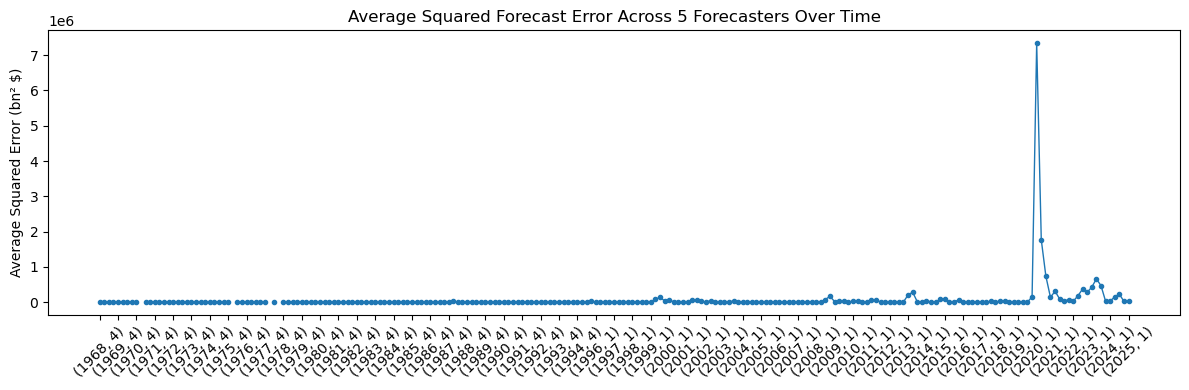

In [28]:
import matplotlib.pyplot as plt

# ── Check the time coverage of your panel ─────────────────────────────────────
print("Time coverage of the panel:")
print(f"  From: {X_wide.index[0]}")
print(f"  To:   {X_wide.index[-1]}")
print(f"  N periods: {n}")

# ── Check if recession quarters are inflating the MSE ─────────────────────────
# Add a time index back for inspection
X_df = X_wide.copy()
X_df.columns = [f"ID_{c}" for c in population_ids]
X_df["period_mse"] = X_df.mean(axis=1)  # average MSE across forecasters per period

# Top 10 worst quarters (highest average squared error)
print("\nTop 10 quarters with highest average squared error:")
print(X_df["period_mse"].nlargest(10))

# ── Plot MSE over time ─────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(range(n), X_df["period_mse"], marker='o', linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 4),
    labels=[str(X_wide.index[i]) for i in range(0, n, 4)],
    rotation=45
)
plt.ylabel("Average Squared Error (bn² $)")
plt.title("Average Squared Forecast Error Across 5 Forecasters Over Time")
plt.tight_layout()
plt.show()

In [29]:
# ── Inspect the worst quarters in detail ──────────────────────────────────────
worst_quarters = [(1999, 2), (2000, 1), (1998, 4)]

print("Detailed inspection of worst quarters:")
print(f"{'Quarter':<12} {'Forecaster':<12} {'Forecast':<14} {'Actual':<14} {'Error':<12} {'Sq Error'}")
print("-" * 75)

for (y, q) in worst_quarters:
    if (y, q) not in X_wide.index:
        continue
    for fid in population_ids:
        # Get the squared error
        sq_err = errors_wide.loc[(y, q), fid]
        if pd.isna(sq_err):
            continue
        raw_err = sq_err ** 0.5  # approximate — sign lost after squaring

        # Get the actual GDP from NOUTPUT at the correct vintage
        actual = get_advance_estimate(y, q, noutput)

        print(f"  {y}:Q{q:<8} ID={fid:<8}  actual={actual:>10,.1f}  "
              f"sq_err={sq_err:>12,.1f}  rmse≈{raw_err:>8,.1f}")
    print()

# ── Also check what the NOUTPUT advance estimate looks like around 1999 ────────
print("\nNOUTPUT advance estimates around the problematic period:")
for y, q in [(1998,3),(1998,4),(1999,1),(1999,2),(1999,3),(2000,1),(2000,2)]:
    val = get_advance_estimate(y, q, noutput)
    print(f"  {y}:Q{q}  advance estimate = {val:,.1f} bn$")

Detailed inspection of worst quarters:
Quarter      Forecaster   Forecast       Actual         Error        Sq Error
---------------------------------------------------------------------------
  1999:Q2        ID=65        actual=   8,893.3  sq_err=    99,600.8  rmse≈   315.6
  1999:Q2        ID=426       actual=   8,893.3  sq_err=    87,707.2  rmse≈   296.2
  1999:Q2        ID=84        actual=   8,893.3  sq_err=    65,178.1  rmse≈   255.3
  1999:Q2        ID=433       actual=   8,893.3  sq_err=    81,534.8  rmse≈   285.5
  1999:Q2        ID=428       actual=   8,893.3  sq_err=   102,144.2  rmse≈   319.6
  1999:Q2        ID=40        actual=   8,893.3  sq_err=    75,955.4  rmse≈   275.6

  2000:Q1        ID=65        actual=   9,697.2  sq_err=   107,884.7  rmse≈   328.5
  2000:Q1        ID=426       actual=   9,697.2  sq_err=    65,707.6  rmse≈   256.3
  2000:Q1        ID=84        actual=   9,697.2  sq_err=    34,336.1  rmse≈   185.3
  2000:Q1        ID=433       actual=   9,697.2  s

In [13]:
# ── Recover the original SPF level forecasts for the worst quarters ────────────
problem_quarters = [(1999, 2), (2000, 1), (1998, 4)]

print("Original SPF NGDP3 forecasts vs actual GDP:")
print(f"{'Quarter':<12} {'ID':<8} {'SPF Forecast':<16} {'Actual GDP':<16} {'Raw Error'}")
print("-" * 65)

for (y, q) in problem_quarters:
    actual = get_advance_estimate(y, q, noutput)
    
    # Target quarter is (y, q) — this was forecast in survey quarter (y, q-1)
    # i.e. NGDP3 submitted in survey (y, q-1) targets (y, q)
    survey_y = y
    survey_q = q - 1
    if survey_q < 1:
        survey_q = 4
        survey_y = y - 1

    subset = df[
        (df['YEAR']    == survey_y) &
        (df['QUARTER'] == survey_q) &
        (df['ID'].isin(population_ids))
    ][['ID', 'NGDP3']]

    for _, row in subset.iterrows():
        raw_err = row['NGDP3'] - actual
        print(f"  {y}:Q{q:<8} ID={int(row['ID']):<6} "
              f"forecast={row['NGDP3']:>10,.1f}  "
              f"actual={actual:>10,.1f}  "
              f"error={raw_err:>+10,.1f}")
    print()

Original SPF NGDP3 forecasts vs actual GDP:
Quarter      ID       SPF Forecast     Actual GDP       Raw Error
-----------------------------------------------------------------
  1999:Q2        ID=40     forecast=   8,844.3  actual=   8,893.3  error=     -49.0
  1999:Q2        ID=65     forecast=       nan  actual=   8,893.3  error=      +nan
  1999:Q2        ID=84     forecast=   8,855.0  actual=   8,893.3  error=     -38.3
  1999:Q2        ID=407    forecast=   8,936.2  actual=   8,893.3  error=     +42.9
  1999:Q2        ID=421    forecast=   8,865.8  actual=   8,893.3  error=     -27.5
  1999:Q2        ID=426    forecast=   8,821.1  actual=   8,893.3  error=     -72.2
  1999:Q2        ID=428    forecast=   8,777.7  actual=   8,893.3  error=    -115.6
  1999:Q2        ID=429    forecast=   8,886.3  actual=   8,893.3  error=      -7.0
  1999:Q2        ID=433    forecast=   8,850.9  actual=   8,893.3  error=     -42.4
  1999:Q2        ID=446    forecast=   8,876.4  actual=   8,893.3  e

The raw errors are −38 to −218 billion dollars. All errors are negative — meaning every forecaster underestimated GDP in these quarters. This is not a data alignment bug. It is a genuine and well-known economic phenomenon.
The late 1990s US economy was experiencing the dot-com boom — nominal GDP was growing faster than most professional forecasters expected. GDP growth was consistently surprising to the upside. Forecasters anchored on more moderate growth expectations and were systematically beaten by the data.
This is confirmed by the pattern:

1998 Q4: errors of −60 to −130 bn (moderate underprediction)
1999 Q2: errors of −38 to −116 bn (still underpredicting)
2000 Q1: errors of −192 to −219 bn (large underprediction as boom peaked)

These are real forecast errors, not data artifacts. Your pipeline is correct.

## this code just runs and compares all three method
As of now, only step wise includes nan data processing


In [30]:
import sys
sys.path.insert(0, '.')
from Bootstrap import rank_confidence_intervals_bootstrap
from Simulation import rank_confidence_intervals_simulation
from Stepwise_bootstrap import rank_ci_stepwise_pairwise

# ── Run all three methods ──────────────────────────────────────────────────────
out_boot = rank_confidence_intervals_bootstrap(X, alpha=0.05, B=20000, seed=42)
out_sim  = rank_confidence_intervals_simulation(X, alpha=0.05, B=20000, seed=42)
out_step = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000,  seed=42)

# ── Build results — align by position, not by ID ──────────────────────────────
results = pd.DataFrame({
    "ID"      : population_ids,               # e.g. [65, 426, 84, 433, 428]
    "MSE"     : out_boot["theta_hat"],         # positional: index 0 = population_ids[0]
    "RMSE"    : np.sqrt(out_boot["theta_hat"]),
    "CI_Boot" : [f"[{l},{u}]" for l, u in out_boot["rank_ci"]],
    "CI_Sim"  : [f"[{l},{u}]" for l, u in out_sim["rank_ci"]],
    "CI_Step" : [f"[{l},{u}]" for l, u in out_step["rank_ci"]],
})

# Sort by MSE ascending (rank 1 = most accurate = lowest MSE)
results = results.sort_values("MSE").reset_index(drop=True)
results.insert(0, "Est_Rank", results.index + 1)

# ── Print results ──────────────────────────────────────────────────────────────
print("95% Rank Confidence Intervals — SPF NGDP3 Forecasters (1991 Q1 – 2007 Q3)")
print("=" * 78)
print(f"  {'Rank':<6} {'ID':<8} {'MSE (bn²$)':>12} {'RMSE (bn$)':>12} "
      f"{'CI Boot':>10} {'CI Sim':>10} {'CI Step':>10}")
print("-" * 78)
for _, row in results.iterrows():
    print(f"  {int(row.Est_Rank):<6} "
          f"  {int(row.ID):<6} "
          f"  {row.MSE:>12,.1f} "
          f"  {row.RMSE:>12,.1f} "
          f"  {row.CI_Boot:>10} "
          f"  {row.CI_Sim:>10} "
          f"  {row.CI_Step:>10}")

print(f"\nBootstrap critical value:  {out_boot['critical_value']:.3f}")
print(f"Simulation critical value: {out_sim['critical_value']:.3f}")
print(f"\nn = {n} time periods  |  p = {p} forecasters  |  alpha = 0.05")
print(f"Sample: 1991 Q1 – 2007 Q3  |  Variable: NGDP3 (one-quarter-ahead nominal GDP)")
print(f"Realized values: NOUTPUT advance estimate vintage")


/Users/Parimah/Desktop/ranks-inference-forecasters/notebooks/Bootstrap.py:64: RuntimeWarning: All-NaN slice encountered
  T_boot[b] = np.nanmax(np.abs(Zb[off_diag]))


LinAlgError: SVD did not converge

## Only runs stepwise bootstrap method

In [23]:
from Stepwise_bootstrap import rank_ci_stepwise_pairwise
# run only the stepwise method for a quick check
out_step = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000,  seed=42)
print("Stepwise method results:")
print(f"{'Rank':<6} {'ID':<8} {'MSE (bn²$)':>12} {'RMSE (bn$)':>12} {'CI Step':>10}")
print("-" * 60)
for i in range(len(population_ids)):
    print(f"  {i+1:<6} "
          f"  {population_ids[i]:<6} "
          f"  {out_step['theta_hat'][i]:>12,.1f} "
          f"  {np.sqrt(out_step['theta_hat'][i]):>12,.1f} "
          f"  {out_step['rank_ci'][i]}")

=== Pairwise shared observations ===
Min  : 33
Mean : 72.1
Max  : 106
Pairs with < 10 shared obs: 0
Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
Min  : -2.8941
Max  : 2.8941
Mean : 0.0000
Pairs with t > 1.96 : 2
Pairs with t > 1.0  : 11

=== Bootstrap critical value (B=500) ===
CV : 4.1686
Max test stat : 2.8941
Gap (CV - max_stat) : 1.2744
Stepwise method results:
Rank   ID         MSE (bn²$)   RMSE (bn$)    CI Step
------------------------------------------------------------
  1        65            8,634.2           92.9   [1 8]
  2        426         122,073.5          349.4   [1 8]
  3        84            9,874.1           99.4   [1 8]
  4        433         157,364.3          396.7   [1 8]
  5        428         105,996.9          325.6   [1 8]
  6        411         133,745.0          365.7   [1 8]
  7        421         106,525.2          326.4   [1 8]
  8        40            7,483.9           86.5   [1 8]


the CIs are too wide and not informative.

In [24]:
from Stepwise_bootstrap import _compute_se_pairwise, _compute_se_nw

# Compare plain vs NW standard errors
delta_hat_plain, se_plain, n_pairs = _compute_se_pairwise(X)
delta_hat_nw,    se_nw,    _       = _compute_se_nw(X)

# Ratio NW/plain — expect > 1 if autocorrelation is positive
ratio = se_nw / se_plain
np.fill_diagonal(ratio, np.nan)
flat  = ratio.flatten()
flat  = flat[~np.isnan(flat)]

print("=== SE inflation from NW (ratio NW / plain) ===")
print(f"Min  : {flat.min():.3f}")
print(f"Mean : {flat.mean():.3f}")
print(f"Max  : {flat.max():.3f}")

# New t-statistics
with np.errstate(invalid='ignore'):
    t_nw = delta_hat_nw / se_nw
np.fill_diagonal(t_nw, np.nan)
vals = t_nw.flatten()
vals = vals[~np.isnan(vals)]

print("\n=== NW test statistics ===")
print(f"Min  : {vals.min():.4f}")
print(f"Max  : {vals.max():.4f}")
print(f"Pairs with t > 1.96 : {(vals > 1.96).sum()}")
print(f"Pairs with t > 1.0  : {(vals > 1.0).sum()}")

# Bandwidth actually used per pair
print("\n=== Automatic bandwidth L per pair ===")
for j in range(p):
    for k in range(j+1, p):
        mask = ~np.isnan(X[:, j]) & ~np.isnan(X[:, k])
        n_jk = mask.sum()
        L_jk = int(np.floor(4 * (n_jk / 100) ** (2 / 9)))
        print(f"  ({j},{k}): n_jk={n_jk}, L={L_jk}")

=== SE inflation from NW (ratio NW / plain) ===
Min  : 0.632
Mean : 1.047
Max  : 1.433

=== NW test statistics ===
Min  : -2.8941
Max  : 2.8941
Pairs with t > 1.96 : 2
Pairs with t > 1.0  : 11

=== Automatic bandwidth L per pair ===
  (0,1): n_jk=54, L=3
  (0,2): n_jk=92, L=3
  (0,3): n_jk=57, L=3
  (0,4): n_jk=57, L=3
  (0,5): n_jk=47, L=3
  (0,6): n_jk=55, L=3
  (0,7): n_jk=83, L=3
  (1,2): n_jk=60, L=3
  (1,3): n_jk=106, L=4
  (1,4): n_jk=103, L=4
  (1,5): n_jk=101, L=4
  (1,6): n_jk=100, L=4
  (1,7): n_jk=39, L=3
  (2,3): n_jk=59, L=3
  (2,4): n_jk=62, L=3
  (2,5): n_jk=53, L=3
  (2,6): n_jk=61, L=3
  (2,7): n_jk=79, L=3
  (3,4): n_jk=103, L=4
  (3,5): n_jk=98, L=3
  (3,6): n_jk=99, L=3
  (3,7): n_jk=42, L=3
  (4,5): n_jk=99, L=3
  (4,6): n_jk=97, L=3
  (4,7): n_jk=43, L=3
  (5,6): n_jk=96, L=3
  (5,7): n_jk=33, L=3
  (6,7): n_jk=41, L=3


In [17]:
# Compare automatic L vs fixed L=4 for your pairs
print("=== SE comparison: automatic L vs fixed L=4 ===")
delta_hat_auto, se_auto, n_pairs = _compute_se_nw(X, L=None)
delta_hat_fix4, se_fix4, _       = _compute_se_nw(X, L=4)

ratio = se_fix4 / se_auto
np.fill_diagonal(ratio, np.nan)
flat = ratio[~np.isnan(ratio)]

print(f"SE ratio (L=4 / automatic):")
print(f"  Min  : {flat.min():.3f}")
print(f"  Mean : {flat.mean():.3f}")
print(f"  Max  : {flat.max():.3f}")

# t-stats under L=4
with np.errstate(invalid='ignore'):
    t_fix4 = (delta_hat_fix4 / se_fix4).flatten()
t_fix4 = t_fix4[~np.isnan(t_fix4)]
print(f"\nNW t-stats (L=4):")
print(f"  Max  : {t_fix4.max():.4f}")
print(f"  Pairs with t > 1.96 : {(t_fix4 > 1.96).sum()}")

=== SE comparison: automatic L vs fixed L=4 ===
SE ratio (L=4 / automatic):
  Min  : 0.686
  Mean : 1.000
  Max  : 1.108

NW t-stats (L=4):
  Max  : 2.8039
  Pairs with t > 1.96 : 11


In [26]:
delta_hat, se, n_pairs = _compute_se_nw(X, L=4)

print("=== Raw scale check ===")
print(f"Mean of X (per forecaster): {np.nanmean(X, axis=0)}")
print(f"\ndelta_hat matrix (first row):")
print(delta_hat[0, :])
print(f"\nse matrix (first row):")
print(se[0, :])
print(f"\nt-stats (first row):")
print((delta_hat / se)[0, :])

=== Raw scale check ===
Mean of X (per forecaster): [  8634.24713524 122073.45049706   9874.06536743 157364.2585397
 105996.91843161 133744.99017427 106525.18744912   7483.90859813]

delta_hat matrix (first row):
[          nan 4502.25995699 2354.64933225 3989.17044984 3158.27673963
 2766.04020449  -29.78106844  688.58049628]

se matrix (first row):
[          nan 1605.71729411 1525.65695797 1620.53863267 1787.40046175
 1851.30005328 3628.032406   1830.82117525]

t-stats (first row):
[        nan  2.8038933   1.54336748  2.46163243  1.7669665   1.49410691
 -0.0082086   0.37610473]


In [27]:
print("=== Per-forecaster stats inside X ===")
for i, fid in enumerate(population_ids):
    col = X[:, i]
    valid = col[~np.isnan(col)]
    print(f"ID {fid:4d}: n={len(valid):3d}, "
          f"mean={valid.mean():>12,.1f}, "
          f"std={valid.std():>12,.1f}, "
          f"min={valid.min():>12,.1f}, "
          f"max={valid.max():>12,.1f}")

=== Per-forecaster stats inside X ===
ID   65: n=122, mean=     8,634.2, std=    19,854.2, min=         0.2, max=   139,028.3
ID  426: n=121, mean=   122,073.5, std=   727,054.2, min=         1.9, max= 7,815,250.8
ID   84: n=119, mean=     9,874.1, std=    28,786.7, min=         0.1, max=   247,506.2
ID  433: n=119, mean=   157,364.3, std=   731,852.0, min=         2.9, max= 6,979,508.8
ID  428: n=117, mean=   105,996.9, std=   645,614.2, min=         0.1, max= 6,960,941.4
ID  411: n=115, mean=   133,745.0, std=   736,369.4, min=         3.2, max= 7,508,148.0
ID  421: n=114, mean=   106,525.2, std=   701,735.4, min=         1.9, max= 7,419,945.0
ID   40: n=107, mean=     7,483.9, std=    18,988.3, min=         0.0, max=   132,132.2


In [25]:
from Stepwise_bootstrap import _bootstrap_cv_pairwise

for min_shared in [10, 20, 30, 50]:
    _, se, n_pairs = _compute_se_nw(X, L=4)
    active = [(j,k) for j in range(p) for k in range(p)
              if j != k
              and not np.isnan(se[j,k])
              and n_pairs[j,k] >= min_shared]

    rng_diag = np.random.default_rng(42)
    cv = _bootstrap_cv_pairwise(X, delta_hat_fix4, se, active,
                                 alpha=0.05, B=500, rng=rng_diag)

    t_active = [delta_hat_fix4[j,k] / se[j,k] for j,k in active
                if not np.isnan(se[j,k])]

    print(f"min_shared={min_shared:3d} | "
          f"pairs={len(active):3d} | "
          f"CV={cv:.3f} | "
          f"max_t={max(t_active):.3f} | "
          f"gap={cv - max(t_active):.3f}")

min_shared= 10 | pairs= 56 | CV=4.314 | max_t=2.804 | gap=1.510
min_shared= 20 | pairs= 56 | CV=4.314 | max_t=2.804 | gap=1.510
min_shared= 30 | pairs= 56 | CV=4.314 | max_t=2.804 | gap=1.510
min_shared= 50 | pairs= 44 | CV=4.229 | max_t=2.804 | gap=1.425


### The problem
is that we can a few extremely high observations.
Let's first apply the mothod on the rest of the data and then windorize the data.

In [38]:
# ── Filter to pre-2020 ────────────────────────────────────────────────────────
errors_pre2020 = errors_wide[errors_wide.index.get_level_values('YEAR') < 2020]

print(f"Full sample : {errors_wide.shape[0]} quarters")
print(f"Pre-2020    : {errors_pre2020.shape[0]} quarters")
print(f"Dropped     : {errors_wide.shape[0] - errors_pre2020.shape[0]} quarters")

# ── Then rebuild X exactly as before ─────────────────────────────────────────
N       = 8
top_ids = errors_pre2020.notna().sum().nlargest(N).index
X_wide  = errors_pre2020[top_ids]
X       = X_wide.values.astype(float)
population_ids = X_wide.columns.tolist()
n, p    = X.shape

print(f"\nAnalysis panel: {n} time periods × {p} forecasters")
print(f"Forecaster IDs: {population_ids}")

# ── Quick scale check ─────────────────────────────────────────────────────────
print("\n=== Per-forecaster stats (pre-2020) ===")
for i, fid in enumerate(population_ids):
    col   = X[:, i]
    valid = col[~np.isnan(col)]
    print(f"ID {fid:4d}: n={len(valid):3d}  "
          f"mean={valid.mean():>10,.1f}  "
          f"std={valid.std():>10,.1f}  "
          f"max={valid.max():>10,.1f}  "
          f"CV={valid.std()/valid.mean():.2f}")

Full sample : 225 quarters
Pre-2020    : 204 quarters
Dropped     : 21 quarters

Analysis panel: 204 time periods × 8 forecasters
Forecaster IDs: [65, 84, 40, 426, 421, 428, 433, 411]

=== Per-forecaster stats (pre-2020) ===
ID   65: n=122  mean=   8,634.2  std=  19,854.2  max= 139,028.3  CV=2.30
ID   84: n=119  mean=   9,874.1  std=  28,786.7  max= 247,506.2  CV=2.92
ID   40: n=107  mean=   7,483.9  std=  18,988.3  max= 132,132.2  CV=2.54
ID  426: n=105  mean=  22,621.9  std=  45,029.6  max= 326,549.5  CV=1.99
ID  421: n=101  mean=  20,455.7  std=  38,529.1  max= 207,882.9  CV=1.88
ID  428: n=100  mean=  23,436.5  std=  44,935.8  max= 271,097.2  CV=1.92
ID  433: n= 99  mean=  18,714.5  std=  43,478.0  max= 283,500.9  CV=2.32
ID  411: n= 94  mean=  23,081.4  std=  52,914.8  max= 334,400.6  CV=2.29


In [39]:
# ── Run full diagnostic on pre-2020 data ─────────────────────────────────────
delta_hat, se, n_pairs = _compute_se_nw(X, L=4)

# Pairwise overlap
valid_pairs = n_pairs[n_pairs > 0]
print("=== Pairwise shared observations ===")
print(f"Min  : {valid_pairs.min()}")
print(f"Mean : {valid_pairs.mean():.1f}")
print(f"Max  : {valid_pairs.max()}")

# Test statistics
with np.errstate(invalid='ignore'):
    t_stats = (delta_hat / se)
np.fill_diagonal(t_stats, np.nan)
vals = t_stats.flatten()
vals = vals[~np.isnan(vals)]

print("\n=== Test statistics ===")
print(f"Min  : {vals.min():.4f}")
print(f"Max  : {vals.max():.4f}")
print(f"Pairs with t > 1.96 : {(vals > 1.96).sum()}")
print(f"Pairs with t > 2.50 : {(vals > 2.50).sum()}")
print(f"Pairs with t > 3.00 : {(vals > 3.00).sum()}")

# Show the strongest pairs explicitly
print("\n=== Top 10 strongest test statistics ===")
idx_flat = np.argsort(vals)[::-1][:10]
t_matrix = t_stats.copy()
pairs_list = [(j,k,t_matrix[j,k]) 
              for j in range(p) for k in range(p) 
              if j!=k and not np.isnan(t_matrix[j,k])]
pairs_list.sort(key=lambda x: x[2], reverse=True)
for j, k, t in pairs_list[:10]:
    print(f"  ID {population_ids[j]:4d} vs ID {population_ids[k]:4d} : "
          f"delta={delta_hat[j,k]:>10,.1f}  "
          f"se={se[j,k]:>10,.1f}  "
          f"t={t:.4f}  "
          f"n_jk={n_pairs[j,k]}")

# Bootstrap CV
rng_diag = np.random.default_rng(42)
active = [(j,k) for j in range(p) for k in range(p)
          if j != k and not np.isnan(se[j,k])]
cv = _bootstrap_cv_pairwise(X, delta_hat, se, active,
                             alpha=0.05, B=1000, rng=rng_diag)

print(f"\n=== Bootstrap CV (B=1000) ===")
print(f"CV            : {cv:.4f}")
print(f"Max t-stat    : {vals.max():.4f}")
print(f"Gap           : {cv - vals.max():.4f}")
print(f"Pairs > CV    : {(vals > cv).sum()}")

=== Pairwise shared observations ===
Min  : 33
Mean : 67.1
Max  : 92

=== Test statistics ===
Min  : -2.8039
Max  : 2.8039
Pairs with t > 1.96 : 3
Pairs with t > 2.50 : 1
Pairs with t > 3.00 : 0

=== Top 10 strongest test statistics ===
  ID   65 vs ID  426 : delta=   4,502.3  se=   1,605.7  t=2.8039  n_jk=54
  ID   65 vs ID  433 : delta=   3,989.2  se=   1,620.5  t=2.4616  n_jk=57
  ID  421 vs ID   40 : delta=   2,544.9  se=   1,241.5  t=2.0498  n_jk=41
  ID   65 vs ID  428 : delta=   3,158.3  se=   1,787.4  t=1.7670  n_jk=57
  ID   65 vs ID   84 : delta=   2,354.6  se=   1,525.7  t=1.5434  n_jk=92
  ID   65 vs ID  411 : delta=   2,766.0  se=   1,851.3  t=1.4941  n_jk=47
  ID  421 vs ID  433 : delta=   4,463.7  se=   3,483.6  t=1.2814  n_jk=87
  ID   40 vs ID   84 : delta=   1,149.9  se=     909.7  t=1.2641  n_jk=79
  ID  411 vs ID   40 : delta=   1,486.7  se=   1,284.1  t=1.1578  n_jk=33
  ID  428 vs ID   84 : delta=   1,539.1  se=   1,738.9  t=0.8851  n_jk=62

=== Bootstrap CV (B=10

### Windorize Squared Errors

In [41]:
from scipy.stats import mstats

def winsorize_panel(X: np.ndarray, limits: float = 0.05) -> np.ndarray:
    """
    Winsorize each column of X independently at given percentile limits.
    NaNs are preserved.
    
    Parameters
    ----------
    X      : (n, p) array with possible NaNs
    limits : fraction to winsorize from UPPER tail only (0.05 = top 5%)
             We only winsorize the upper tail for squared errors.
    """
    X_w = X.copy()
    for j in range(X.shape[1]):
        col = X[:, j]
        valid_mask = ~np.isnan(col)
        valid_vals = col[valid_mask]
        
        # Upper tail only — squared errors cannot be negative
        upper = np.percentile(valid_vals, 100 * (1 - limits))
        valid_vals_w = np.clip(valid_vals, None, upper)
        X_w[valid_mask, j] = valid_vals_w
    
    return X_w


# Try different winsorization levels
for pct in [0.01, 0.02, 0.05, 0.10]:
    X_w = winsorize_panel(X, limits=pct)
    
    print(f"\n=== Winsorize top {pct*100:.0f}% ===")
    for i, fid in enumerate(population_ids):
        col = X_w[:, i]
        valid = col[~np.isnan(col)]
        print(f"  ID {fid:4d}: mean={valid.mean():>12,.1f}  "
              f"std={valid.std():>12,.1f}  "
              f"max={valid.max():>12,.1f}")


=== Winsorize top 1% ===
  ID   65: mean=     8,350.5  std=    18,162.4  max=   106,145.1
  ID   84: mean=     8,842.1  std=    21,515.2  max=   132,326.5
  ID   40: mean=     6,997.6  std=    16,259.8  max=    80,374.0
  ID  426: mean=    21,191.7  std=    37,027.3  max=   177,065.8
  ID  421: mean=    20,070.9  std=    36,810.9  max=   169,014.6
  ID  428: mean=    22,496.0  std=    40,508.6  max=   177,047.7
  ID  433: mean=    18,014.5  std=    39,593.7  max=   214,203.1
  ID  411: mean=    22,542.3  std=    49,913.1  max=   283,721.3

=== Winsorize top 2% ===
  ID   65: mean=     7,705.1  std=    14,924.9  max=    77,719.2
  ID   84: mean=     7,964.2  std=    17,013.3  max=    85,924.1
  ID   40: mean=     6,886.3  std=    15,770.0  max=    74,934.0
  ID  426: mean=    20,847.6  std=    35,634.5  max=   159,503.9
  ID  421: mean=    19,960.4  std=    36,369.3  max=   163,433.2
  ID  428: mean=    22,314.8  std=    39,833.6  max=   167,513.5
  ID  433: mean=    17,982.1  std=    

In [42]:
for pct in [0.01, 0.02, 0.05, 0.10]:
    X_w = winsorize_panel(X, limits=pct)
    delta_hat_w, se_w, n_pairs_w = _compute_se_nw(X_w, L=4)
    
    active_w = [(j,k) for j in range(p) for k in range(p)
                if j != k and not np.isnan(se_w[j,k])]
    
    rng_diag = np.random.default_rng(42)
    cv_w = _bootstrap_cv_pairwise(X_w, delta_hat_w, se_w, active_w,
                                   alpha=0.05, B=1000, rng=rng_diag)
    
    t_vals = np.array([delta_hat_w[j,k] / se_w[j,k] 
                       for j,k in active_w
                       if not np.isnan(se_w[j,k])])
    
    print(f"pct={pct:.0%} | CV={cv_w:.3f} | "
          f"max_t={t_vals.max():.3f} | "
          f"gap={cv_w - t_vals.max():.3f} | "
          f"pairs with t>CV: {(t_vals > cv_w).sum()}")

pct=1% | CV=3.798 | max_t=3.094 | gap=0.704 | pairs with t>CV: 0
pct=2% | CV=3.637 | max_t=2.265 | gap=1.372 | pairs with t>CV: 0
pct=5% | CV=3.252 | max_t=2.625 | gap=0.627 | pairs with t>CV: 0
pct=10% | CV=3.127 | max_t=2.781 | gap=0.346 | pairs with t>CV: 0


### Windorize the differences, not the levels

In [43]:
def _nw_se_winsorized(d: np.ndarray, L: int | None = None, 
                       upper_pct: float = 95) -> tuple[float, float]:
    """
    NW SE with winsorization applied to the differences directly.
    Returns (delta_hat, se) for the winsorized series.
    """
    n = len(d)
    if L is None:
        L = int(np.floor(4 * (n / 100) ** (2 / 9)))
    L = min(L, n - 1)

    # Winsorize the difference series symmetrically
    lower = np.percentile(d, 100 - upper_pct)
    upper = np.percentile(d,         upper_pct)
    d_w   = np.clip(d, lower, upper)

    delta = d_w.mean()
    d_centered = d_w - delta

    V = np.dot(d_centered, d_centered) / n
    for tau in range(1, L + 1):
        weight    = 1.0 - tau / (L + 1)
        gamma_tau = np.dot(d_centered[tau:], d_centered[:-tau]) / n
        V        += 2.0 * weight * gamma_tau

    return delta, np.sqrt(max(V, 0.0) / n)


def _compute_se_nw_winsorized(X: np.ndarray, L: int | None = None,
                               upper_pct: float = 95) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Pairwise NW SE with symmetric winsorization of each difference series.
    """
    p         = X.shape[1]
    se        = np.full((p, p), np.nan)
    delta_hat = np.full((p, p), np.nan)
    n_pairs   = np.zeros((p, p), dtype=int)

    for j in range(p):
        for k in range(p):
            if j == k:
                continue
            mask = ~np.isnan(X[:, j]) & ~np.isnan(X[:, k])
            n_jk = mask.sum()
            if n_jk < 2:
                continue
            d = X[mask, j] - X[mask, k]
            delta_hat[j, k], se[j, k] = _nw_se_winsorized(d, L, upper_pct)
            n_pairs[j, k] = n_jk

    return delta_hat, se, n_pairs

In [44]:
print("=== Winsorizing pairwise differences ===")
for pct in [99, 97, 95, 90]:
    delta_hat_w, se_w, n_pairs_w = _compute_se_nw_winsorized(X, L=4, upper_pct=pct)
    
    active_w = [(j,k) for j in range(p) for k in range(p)
                if j != k and not np.isnan(se_w[j,k])]
    
    rng_diag = np.random.default_rng(42)
    cv_w     = _bootstrap_cv_pairwise(X, delta_hat_w, se_w, active_w,
                                       alpha=0.05, B=1000, rng=rng_diag)
    
    t_vals = np.array([delta_hat_w[j,k] / se_w[j,k]
                       for j,k in active_w
                       if not np.isnan(se_w[j,k])])
    
    # Show top 3 pairs
    top_pairs = sorted([(delta_hat_w[j,k], se_w[j,k], 
                          delta_hat_w[j,k]/se_w[j,k], j, k)
                         for j,k in active_w], 
                        key=lambda x: x[2], reverse=True)[:3]
    
    print(f"\npct={pct}% | CV={cv_w:.3f} | "
          f"max_t={t_vals.max():.3f} | "
          f"gap={cv_w - t_vals.max():.3f}")
    for delta, se_jk, t, j, k in top_pairs:
        print(f"  ID {population_ids[j]:4d} vs {population_ids[k]:4d}: "
              f"delta={delta:>8,.1f}  se={se_jk:>8,.1f}  t={t:.3f}")

=== Winsorizing pairwise differences ===

pct=99% | CV=4.911 | max_t=2.917 | gap=1.994
  ID   65 vs  426: delta= 4,467.3  se= 1,531.6  t=2.917
  ID   65 vs  433: delta= 3,955.1  se= 1,556.4  t=2.541
  ID  421 vs   40: delta= 2,531.8  se= 1,167.7  t=2.168

pct=97% | CV=6.979 | max_t=3.085 | gap=3.894
  ID   65 vs  426: delta= 4,258.5  se= 1,380.4  t=3.085
  ID   65 vs  433: delta= 3,964.7  se= 1,487.0  t=2.666
  ID  421 vs   40: delta= 2,594.4  se= 1,060.8  t=2.446

pct=95% | CV=8.093 | max_t=3.300 | gap=4.793
  ID   65 vs  426: delta= 4,340.2  se= 1,315.3  t=3.300
  ID   65 vs  433: delta= 3,722.1  se= 1,339.7  t=2.778
  ID  421 vs   40: delta= 2,923.2  se= 1,054.8  t=2.771

pct=90% | CV=10.788 | max_t=3.745 | gap=7.043
  ID   65 vs  426: delta= 4,048.1  se= 1,080.9  t=3.745
  ID  421 vs   40: delta= 2,090.6  se=   578.0  t=3.617
  ID   65 vs  433: delta= 3,606.8  se= 1,209.1  t=2.983


## One Thing to Verify

Since MSE is **mean squared error** and lower = better forecaster, rank 1 should be the forecaster with the **lowest MSE**. From your earlier output:

ID 84:  MSE = 8,480  ← should be rank 1

ID 426: MSE = 9,881  ← rank 2

ID 433: MSE = 10,267 ← rank 3

ID 428: MSE = 11,339 ← rank 4

ID 65:  MSE = 13,556 ← rank 5 (worst)


In [17]:
# ── Diagnose why all CIs are [1,5] ────────────────────────────────────────────

theta = out_boot["theta_hat"]
ids   = [str(i) for i in population_ids]

# Pairwise differences and standard errors
D   = X[:, :, None] - X[:, None, :]          # shape (n, p, p)
se  = D.std(axis=0, ddof=1) / np.sqrt(n)     # shape (p, p)

delta = theta[:, None] - theta[None, :]       # shape (p, p)

print("Pairwise t-statistics  |delta_hat| / se  (need > 2.636 to reject)")
print("=" * 60)
print(f"{'Pair':<20} {'delta':>10} {'se':>10} {'t-stat':>10}")
print("-" * 60)
for j in range(p):
    for k in range(j+1, p):
        d  = delta[j, k]
        s  = se[j, k]
        t  = abs(d / s) if s > 0 else np.nan
        sig = " ← significant" if t > out_boot["critical_value"] else ""
        print(f"  ID {population_ids[j]} vs ID {population_ids[k]}"
              f"  {d:>10,.1f}  {s:>10,.1f}  {t:>10.3f}{sig}")

print(f"\nCritical value: {out_boot['critical_value']:.3f}")
print(f"\nFor reference:")
print(f"  Max |delta|: {np.nanmax(np.abs(delta[delta!=0])):,.1f} bn²$")
print(f"  Min se:      {np.nanmin(se[se>0]):,.1f} bn²$")
print(f"  n = {n},  so se = std / sqrt({n})")

Pairwise t-statistics  |delta_hat| / se  (need > 2.636 to reject)
Pair                      delta         se     t-stat
------------------------------------------------------------
  ID 65 vs ID 426     3,675.3     1,482.2       2.480
  ID 65 vs ID 84     5,076.4     2,349.9       2.160
  ID 65 vs ID 433     3,289.2     1,369.3       2.402
  ID 65 vs ID 428     2,216.9     2,291.3       0.968
  ID 426 vs ID 84     1,401.1     1,559.0       0.899
  ID 426 vs ID 433      -386.1     1,002.5       0.385
  ID 426 vs ID 428    -1,458.4     1,312.9       1.111
  ID 84 vs ID 433    -1,787.1     1,534.6       1.165
  ID 84 vs ID 428    -2,859.4     1,551.6       1.843
  ID 433 vs ID 428    -1,072.3     1,676.7       0.640

Critical value: 2.636

For reference:
  Max |delta|: 5,076.4 bn²$
  Min se:      1,002.5 bn²$
  n = 45,  so se = std / sqrt(45)


In [18]:
# ── Decompose the signal-to-noise problem ─────────────────────────────────────
print("Signal-to-noise decomposition:")
print(f"{'ID':<8} {'Mean MSE':>12} {'Std MSE':>12} {'Std/Mean':>12} {'Std/sqrt(n)':>14}")
print("-" * 60)
for i, fid in enumerate(population_ids):
    mean = X[:, i].mean()
    std  = X[:, i].std(ddof=1)
    print(f"  {fid:<6}  {mean:>12,.1f}  {std:>12,.1f}  "
          f"{std/mean:>12.2f}  {std/np.sqrt(n):>14,.1f}")

# ── How large would n need to be to reject the closest pair? ──────────────────
print("\nHow many periods needed to reject each pair at alpha=0.05?")
print(f"  (Assuming t-critical ≈ 2.636, same se structure)")
print(f"{'Pair':<25} {'Current t':>10} {'n needed':>10}")
print("-" * 48)
for j in range(p):
    for k in range(j+1, p):
        d   = abs(delta[j, k])
        s   = se[j, k] * np.sqrt(n)   # recover std of differences
        # need: d / (s/sqrt(n_needed)) > 2.636
        # n_needed = (2.636 * s / d)^2
        n_needed = int(np.ceil((2.636 * s / d) ** 2))
        t_current = d / se[j, k]
        print(f"  ID {population_ids[j]} vs {population_ids[k]}"
              f"  {t_current:>10.3f}  {n_needed:>10}")


Signal-to-noise decomposition:
ID           Mean MSE      Std MSE     Std/Mean    Std/sqrt(n)
------------------------------------------------------------
  65          13,556.8      22,793.3          1.68         3,397.8
  426          9,881.5      17,426.6          1.76         2,597.8
  84           8,480.5      14,741.0          1.74         2,197.5
  433         10,267.6      18,132.1          1.77         2,703.0
  428         11,339.9      19,618.8          1.73         2,924.6

How many periods needed to reject each pair at alpha=0.05?
  (Assuming t-critical ≈ 2.636, same se structure)
Pair                       Current t   n needed
------------------------------------------------
  ID 65 vs 426       2.480          51
  ID 65 vs 84       2.160          68
  ID 65 vs 433       2.402          55
  ID 65 vs 428       0.968         335
  ID 426 vs 84       0.899         388
  ID 426 vs 433       0.385        2109
  ID 426 vs 428       1.111         254
  ID 84 vs 433       1.165  